# 05 - Extraction de la trajectoire

Objectif : extraire la trajectoire ? partir des points d?tect?s dans notre segmentation. Nous ne devons pas utiliser le groundtruth pour suivre l?objet ni pour r?initialiser les points.


## 1. Importation des biblioth?ques


In [1]:
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append("../")
from src.detection import read_groundtruth, extract_roi, preprocess_roi, segment_otsu, segment_adaptive, clean_mask, detect_features_in_mask, compare_masks
from src.optical_flow import compute_lucas_kanade
from src.trajectory import compute_object_center, save_trajectory, draw_trajectory_on_image
plt.rcParams["figure.figsize"] = (12, 6)


## 2. Chargement des images


In [2]:
dataset_path = Path("../data/car/car-11")
img_path = dataset_path / "img"
groundtruth_path = dataset_path / "groundtruth.txt"
results_path = Path("../results")
plots_path = results_path / "plots"
results_path.mkdir(parents=True, exist_ok=True)
plots_path.mkdir(parents=True, exist_ok=True)
image_files = sorted([p for p in img_path.iterdir() if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
max_frames = min(100, len(image_files))
manual_bbox = (535, 295, 220, 110)
print("Nombre de frames utilis?es :", max_frames)
print("ROI manuelle :", manual_bbox)


Nombre de frames utilis?es : 100
ROI manuelle : (535, 295, 220, 110)


## 3. Fonctions utiles

Nous suivons les points frame par frame avec Lucas-Kanade. Si le nombre de points devient inf?rieur ? 5, nous red?tectons des points dans une petite ROI autour de la derni?re position estim?e, sans utiliser le groundtruth.


In [3]:
def preprocess_full(image_bgr):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    return cv2.GaussianBlur(enhanced, (5, 5), 0)

def clip_bbox(bbox, image_shape):
    x, y, w, h = [int(v) for v in bbox]
    height, width = image_shape[:2]
    x = max(0, min(x, width - 1)); y = max(0, min(y, height - 1))
    w = max(1, min(w, width - x)); h = max(1, min(h, height - y))
    return x, y, w, h

def detect_points_by_segmentation(image_bgr, bbox):
    bbox = clip_bbox(bbox, image_bgr.shape)
    x, y, w, h = bbox
    roi_bgr = image_bgr[y:y+h, x:x+w]
    gray_roi = preprocess_roi(roi_bgr)
    mask_otsu = clean_mask(segment_otsu(gray_roi))
    mask_adaptive = clean_mask(segment_adaptive(gray_roi, block_size=31, C=5))
    points_otsu = detect_features_in_mask(gray_roi, mask_otsu)
    points_adaptive = detect_features_in_mask(gray_roi, mask_adaptive)
    method = compare_masks(mask_otsu, mask_adaptive, points_otsu, points_adaptive)
    points = points_adaptive if method == "Adaptive" else points_otsu
    if points is None:
        return None, method, bbox
    points_global = points.copy().astype(np.float32)
    points_global[:, 0, 0] += x
    points_global[:, 0, 1] += y
    return points_global, method, bbox

def bbox_around_center(center, image_shape, base_size):
    base_w, base_h = base_size
    cx, cy = center
    search_w = int(base_w * 1.25); search_h = int(base_h * 1.25)
    return clip_bbox((int(cx - search_w/2), int(cy - search_h/2), search_w, search_h), image_shape)


## 4. Initialisation des points ? partir du meilleur masque de l??tape 03


In [4]:
first_frame = cv2.imread(str(image_files[0]))
points, initial_method, used_bbox = detect_points_by_segmentation(first_frame, manual_bbox)
initial_center = compute_object_center(points)
print("M?thode initiale :", initial_method)
print("Nombre de points initiaux :", 0 if points is None else len(points))
print("Centre initial estim? :", initial_center)


M?thode initiale : Otsu
Nombre de points initiaux : 80
Centre initial estim? : (636.8499755859375, 350.7875061035156)


## 5. Suivi frame par frame

Nous calculons le centre moyen des points suivis et nous l?ajoutons ? `trajectory`. Cette trajectoire est estim?e ? partir de notre segmentation.


In [5]:
trajectory = [initial_center]
tracked_counts = [len(points)]
frames = [0]
prev_gray = preprocess_full(first_frame)
center = initial_center
base_size = (used_bbox[2], used_bbox[3])

for frame_index in range(1, max_frames):
    current_frame = cv2.imread(str(image_files[frame_index]))
    if current_frame is None:
        break
    current_gray = preprocess_full(current_frame)
    good_old, good_new = compute_lucas_kanade(prev_gray, current_gray, points)

    if good_new is not None and len(good_new) >= 5:
        points = good_new.reshape(-1, 1, 2).astype(np.float32)
        center = compute_object_center(points)
        tracked_count = len(points)
    else:
        search_bbox = bbox_around_center(center, current_frame.shape, base_size)
        points, method, _ = detect_points_by_segmentation(current_frame, search_bbox)
        tracked_count = 0 if points is None else len(points)
        if points is None or len(points) < 5:
            print("Suivi arr?t? ? la frame", frame_index)
            break
        center = compute_object_center(points)

    trajectory.append(center)
    tracked_counts.append(tracked_count)
    frames.append(frame_index)
    prev_gray = current_gray

trajectory_df = pd.DataFrame({"frame": frames, "x": [p[0] for p in trajectory], "y": [p[1] for p in trajectory], "tracked_points": tracked_counts})
display(trajectory_df.head())
print("Nombre de positions estim?es :", len(trajectory_df))


,frame,x,y,tracked_points
0,0,636.849976,350.787506,80
1,1,636.511597,350.731049,80
2,2,635.575806,350.584442,80
3,3,634.690430,350.468353,80
4,4,633.782349,350.302094,80


Nombre de positions estim?es : 100


## 6. Sauvegarde de la trajectoire estim?e


Trajectoire sauvegard?e dans : ..\results\trajectory_estimated.csv


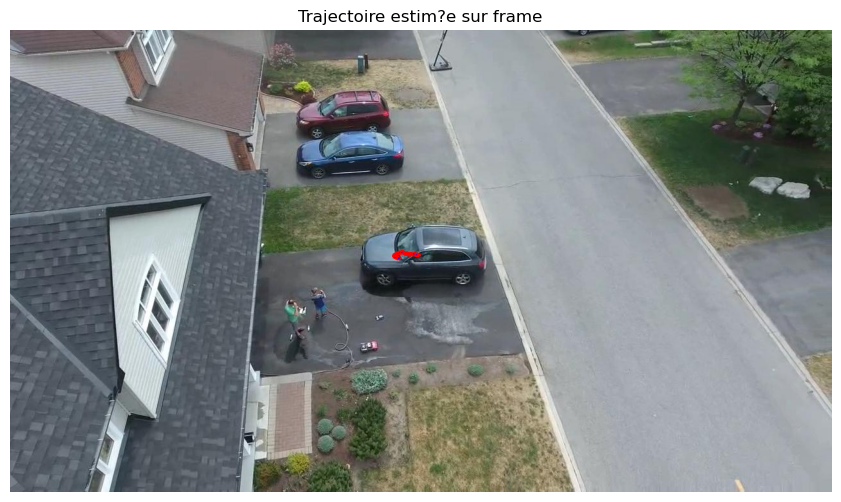

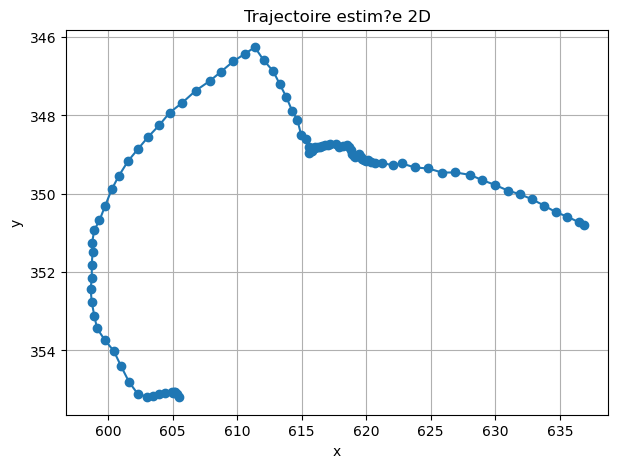

In [6]:
trajectory_csv_path = results_path / "trajectory_estimated.csv"
save_trajectory(trajectory_df, trajectory_csv_path)
print("Trajectoire sauvegard?e dans :", trajectory_csv_path)

trajectory_points = trajectory_df[["x", "y"]].values
trajectory_on_frame = draw_trajectory_on_image(first_frame, trajectory_points)
cv2.imwrite(str(plots_path / "trajectory_estimated_on_frame.png"), trajectory_on_frame)
plt.imshow(cv2.cvtColor(trajectory_on_frame, cv2.COLOR_BGR2RGB))
plt.title("Trajectoire estim?e sur frame")
plt.axis("off")
plt.savefig(plots_path / "trajectory_estimated_on_frame.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(trajectory_df["x"], trajectory_df["y"], marker="o")
plt.gca().invert_yaxis(); plt.title("Trajectoire estim?e 2D"); plt.xlabel("x"); plt.ylabel("y"); plt.grid(True)
plt.savefig(plots_path / "trajectory_estimated_2d.png", dpi=150, bbox_inches="tight")
plt.show()


## Comparaison avec le groundtruth

Le groundtruth est utilis? seulement ici comme r?f?rence pour ?valuer la trajectoire estim?e.


In [7]:
groundtruth = read_groundtruth(groundtruth_path)
rows = []
for _, row in trajectory_df.iterrows():
    frame_index = int(row["frame"])
    if frame_index >= len(groundtruth):
        continue
    gt_x, gt_y, gt_w, gt_h = groundtruth.iloc[frame_index]
    gt_cx = gt_x + gt_w / 2
    gt_cy = gt_y + gt_h / 2
    error = np.sqrt((row["x"] - gt_cx) ** 2 + (row["y"] - gt_cy) ** 2)
    rows.append({"frame": frame_index, "estimated_x": row["x"], "estimated_y": row["y"], "groundtruth_x": gt_cx, "groundtruth_y": gt_cy, "error": error})
comparison_df = pd.DataFrame(rows)
comparison_df.to_csv(results_path / "trajectory_comparison.csv", index=False)
print("Erreur moyenne :", comparison_df["error"].mean())
print("Erreur maximale :", comparison_df["error"].max())
display(comparison_df.head())


Erreur moyenne : 16.408701201615166
Erreur maximale : 23.21730168568301


,frame,estimated_x,estimated_y,groundtruth_x,groundtruth_y,error
0,0,636.849976,350.787506,644.0,350.5,7.155802
1,1,636.511597,350.731049,643.5,346.0,8.439230
2,2,635.575806,350.584442,642.5,345.5,8.590461
3,3,634.690430,350.468353,642.0,345.5,8.838232
4,4,633.782349,350.302094,641.5,346.5,8.603375


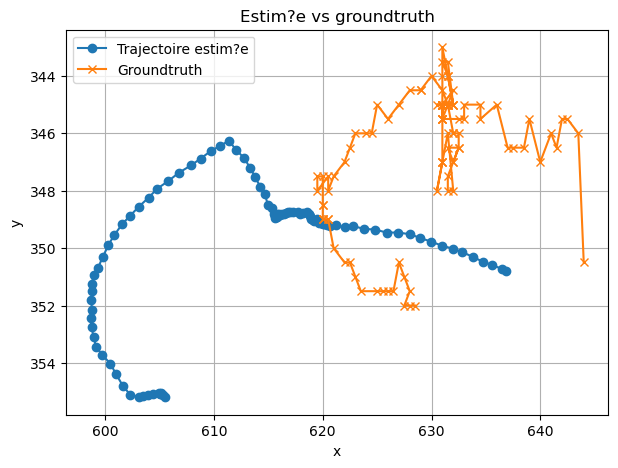

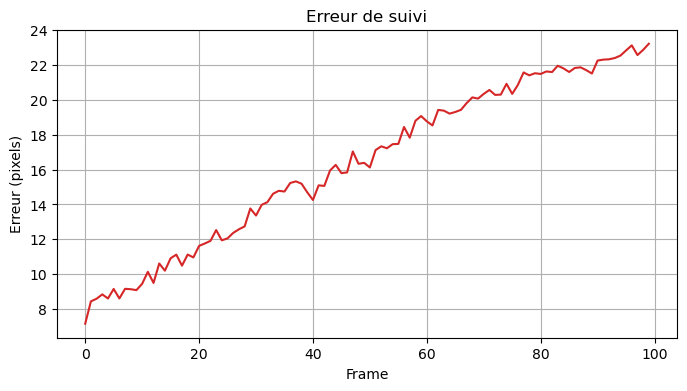

In [8]:
plt.figure(figsize=(7,5))
plt.plot(comparison_df["estimated_x"], comparison_df["estimated_y"], marker="o", label="Trajectoire estim?e")
plt.plot(comparison_df["groundtruth_x"], comparison_df["groundtruth_y"], marker="x", label="Groundtruth")
plt.gca().invert_yaxis(); plt.title("Estim?e vs groundtruth"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(True)
plt.savefig(plots_path / "estimated_vs_groundtruth.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(comparison_df["frame"], comparison_df["error"], color="tab:red")
plt.title("Erreur de suivi"); plt.xlabel("Frame"); plt.ylabel("Erreur (pixels)"); plt.grid(True)
plt.savefig(plots_path / "tracking_error.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Conclusion

Nous avons extrait la trajectoire avec Lucas-Kanade ? partir des points d?tect?s dans notre segmentation. Le groundtruth n?a pas ?t? utilis? pour suivre l?objet. Il sert seulement ? calculer une erreur de comparaison finale.
